<a href="https://colab.research.google.com/github/Ritchie12233/WQD-7012-OCC-11-AQI/blob/main/WQD7012_AQI_Final_Deployment_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WQD7012 AQI GitHub-Based Cloud Deployment Record

This notebook records the cloud deployment by using the same GitHub repository that Streamlit Cloud reads. It clones the deployment source, checks the required Streamlit files and model artifacts, shows the deployed dashboard preview, and then presents the final cloud result.

## 1. GitHub Deployment Source

The deployment source is first loaded from GitHub. This matches the repository source selected in Streamlit Cloud.

In [1]:
# Section 1
# Purpose: Clone the GitHub repository used as the Streamlit Cloud deployment source.
from pathlib import Path
from IPython.display import Markdown, Image, display
import json
import shutil
import subprocess

GITHUB_REPO_URL = "https://github.com/Ritchie12233/WQD-7012-OCC-11-AQI"
BRANCH = "main"
PROJECT_DIR = Path("/tmp/wqd7012_occ11_aqi_deployment_source")

if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)

subprocess.run(
    ["git", "clone", "--depth", "1", "--branch", BRANCH, GITHUB_REPO_URL, str(PROJECT_DIR)],
    check=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
)

print("GitHub repository cloned successfully.")
print(f"Repository: {GITHUB_REPO_URL}")
print(f"Branch: {BRANCH}")
print(f"Local deployment source: {PROJECT_DIR}")


GitHub repository cloned successfully.
Repository: https://github.com/Ritchie12233/WQD-7012-OCC-11-AQI
Branch: main
Local deployment source: /tmp/wqd7012_occ11_aqi_deployment_source


## 2. Streamlit Cloud Entry and Configuration

The cloned repository is checked for the files that Streamlit Cloud needs to build and run the dashboard.

In [2]:
# Section 2
# Purpose: Verify the Streamlit entry file and deployment configuration files.
deployment_files = {
    "Streamlit entry file": PROJECT_DIR / "streamlit_app.py",
    "Python runtime file": PROJECT_DIR / "runtime.txt",
    "Python dependency file": PROJECT_DIR / "requirements.txt",
    "System package file": PROJECT_DIR / "packages.txt",
    "Streamlit configuration": PROJECT_DIR / ".streamlit" / "config.toml",
}

missing_files = [label for label, file_path in deployment_files.items() if not file_path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing deployment files: {missing_files}")

rows = []
for label, file_path in deployment_files.items():
    relative_path = file_path.relative_to(PROJECT_DIR)
    rows.append(f"| {label} | `{relative_path}` | Present |")

print("All required Streamlit Cloud deployment files are present.")
display(Markdown("| Check Item | Repository Path | Status |" + chr(10) + "|---|---|---|" + chr(10) + chr(10).join(rows)))


All required Streamlit Cloud deployment files are present.


| Check Item | Repository Path | Status |
|---|---|---|
| Streamlit entry file | `streamlit_app.py` | Present |
| Python runtime file | `runtime.txt` | Present |
| Python dependency file | `requirements.txt` | Present |
| System package file | `packages.txt` | Present |
| Streamlit configuration | `.streamlit/config.toml` | Present |

## 3. Model Artifacts Used by the Deployed Dashboard

The deployed repository is checked for the trained model artifacts used by the supervised and unsupervised dashboard sections.

In [3]:
# Section 3
# Purpose: Verify that the deployed repository contains the required trained model artifacts.
model_artifacts = {
    "XGBoost classification model": PROJECT_DIR / "simple_xgb_classifier.joblib",
    "Random Forest regression model": PROJECT_DIR / "RF" / "rf_regressor_11_features.joblib",
    "K-Means clustering model": PROJECT_DIR / "kmeans_final.joblib",
    "Isolation Forest model": PROJECT_DIR / "isolation_forest.joblib",
    "Feature scaler": PROJECT_DIR / "deployment_11_feature_standard_scaler.joblib",
    "Supervised metadata": PROJECT_DIR / "metadata.json",
    "Unsupervised metadata": PROJECT_DIR / "unsupervised_metadata.json",
}

missing_artifacts = [label for label, file_path in model_artifacts.items() if not file_path.exists()]
if missing_artifacts:
    raise FileNotFoundError(f"Missing model artifacts: {missing_artifacts}")

artifact_rows = []
for label, file_path in model_artifacts.items():
    relative_path = file_path.relative_to(PROJECT_DIR)
    size_kb = file_path.stat().st_size / 1024
    artifact_rows.append(f"| {label} | `{relative_path}` | {size_kb:.1f} KB |")

print("All deployed model artifacts are present.")
display(Markdown("| Artifact | Repository Path | Size |" + chr(10) + "|---|---|---|" + chr(10) + chr(10).join(artifact_rows)))


All deployed model artifacts are present.


| Artifact | Repository Path | Size |
|---|---|---|
| XGBoost classification model | `simple_xgb_classifier.joblib` | 1275.4 KB |
| Random Forest regression model | `RF/rf_regressor_11_features.joblib` | 31312.5 KB |
| K-Means clustering model | `kmeans_final.joblib` | 286.0 KB |
| Isolation Forest model | `isolation_forest.joblib` | 238.6 KB |
| Feature scaler | `deployment_11_feature_standard_scaler.joblib` | 0.8 KB |
| Supervised metadata | `metadata.json` | 1.1 KB |
| Unsupervised metadata | `unsupervised_metadata.json` | 2.6 KB |

## 4. GitHub to Streamlit Cloud Deployment Mapping

This section shows how the GitHub source is connected to the Streamlit Cloud deployment.

In [4]:
# Section 4
# Purpose: Map the verified GitHub source to the Streamlit Cloud deployment setup.
deployment_mapping = [
    ("1", "GitHub repository", "The verified repository cloned in Section 1 is used as the deployment source."),
    ("2", "Branch", "The main branch is selected for the Streamlit Cloud application."),
    ("3", "Entry file", "streamlit_app.py is used as the application entry point."),
    ("4", "Build input", "Streamlit Cloud reads the checked configuration, model artifacts, and dashboard code."),
    ("5", "Cloud output", "The Streamlit Cloud build publishes the AQI dashboard as a web application."),
]

for step, item, description in deployment_mapping:
    print(f"{step}. {item}: {description}")

mapping_rows = [f"| {step} | {item} | {description} |" for step, item, description in deployment_mapping]
display(Markdown("| Step | Deployment Item | Meaning |" + chr(10) + "|---|---|---|" + chr(10) + chr(10).join(mapping_rows)))


1. GitHub repository: The verified repository cloned in Section 1 is used as the deployment source.
2. Branch: The main branch is selected for the Streamlit Cloud application.
3. Entry file: streamlit_app.py is used as the application entry point.
4. Build input: Streamlit Cloud reads the checked configuration, model artifacts, and dashboard code.
5. Cloud output: The Streamlit Cloud build publishes the AQI dashboard as a web application.


| Step | Deployment Item | Meaning |
|---|---|---|
| 1 | GitHub repository | The verified repository cloned in Section 1 is used as the deployment source. |
| 2 | Branch | The main branch is selected for the Streamlit Cloud application. |
| 3 | Entry file | streamlit_app.py is used as the application entry point. |
| 4 | Build input | Streamlit Cloud reads the checked configuration, model artifacts, and dashboard code. |
| 5 | Cloud output | The Streamlit Cloud build publishes the AQI dashboard as a web application. |

## 5. Post-Deployment Dashboard Preview

After deployment, the dashboard page was opened and checked. The screenshot below is stored in the same GitHub repository and is displayed from the cloned deployment source.

AQI scenario buttons are visible.
Supervised learning outputs are visible.
Unsupervised learning outputs are visible.
Driver View and AQI grade scale are visible.


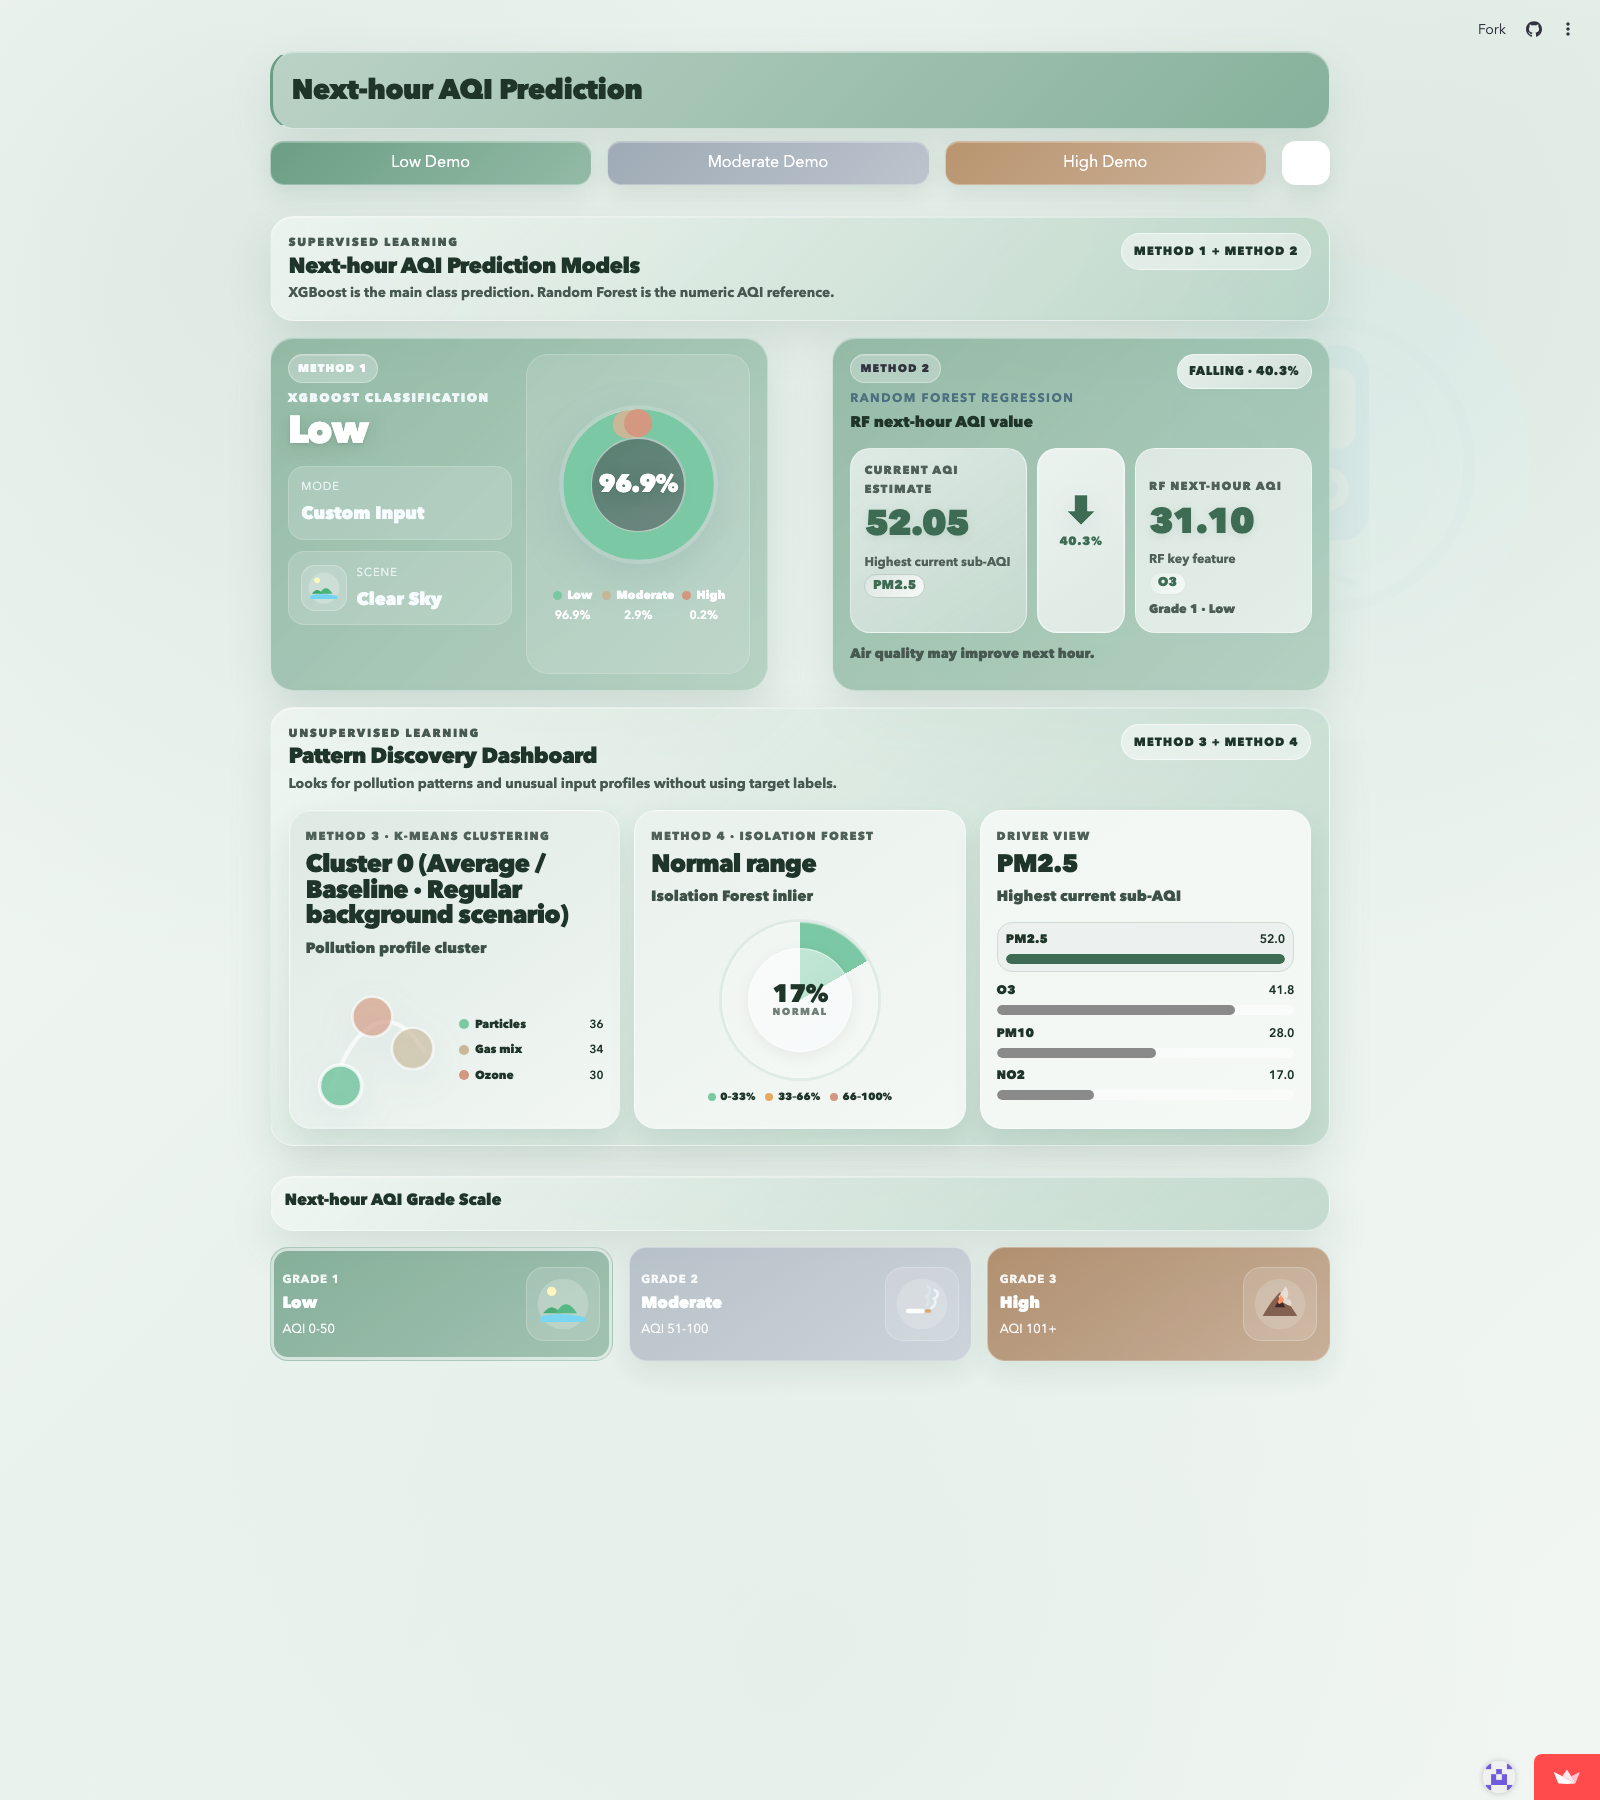

In [5]:
# Section 5
# Purpose: Display the dashboard preview image from the cloned GitHub deployment source.
preview_image = PROJECT_DIR / "assets" / "dashboard_preview.png"
if not preview_image.exists():
    raise FileNotFoundError("Dashboard preview image was not found in the cloned GitHub repository.")

preview_checks = [
    "AQI scenario buttons are visible.",
    "Supervised learning outputs are visible.",
    "Unsupervised learning outputs are visible.",
    "Driver View and AQI grade scale are visible.",
]

for check_item in preview_checks:
    print(check_item)

display(Image(filename=str(preview_image), width=900))


## 6. Final Cloud Deployment Result

The final web application link is shown after verifying the GitHub deployment source and the deployed dashboard preview.

In [6]:
# Section 6
# Purpose: Display the final Streamlit Cloud application link after the deployment source checks.
CLOUD_URL = "https://wqd-7012-occ-11-aqi-2gwknzj37jmwkxoyhasnhm.streamlit.app/"

link_markdown = "## Open Final AQI Dashboard" + chr(10) + f"[Launch the Streamlit App]({CLOUD_URL})"
display(Markdown(link_markdown))
print("Final deployed AQI dashboard:", CLOUD_URL)


## Open Final AQI Dashboard
[Launch the Streamlit App](https://wqd-7012-occ-11-aqi-2gwknzj37jmwkxoyhasnhm.streamlit.app/)

Final deployed AQI dashboard: https://wqd-7012-occ-11-aqi-2gwknzj37jmwkxoyhasnhm.streamlit.app/
